In [1]:
# notebook debugging preamble
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
def wave(freq, phase, t):
    return np.cos(2 * np.pi * freq * t + phase)

In [14]:
duration = 20
period = 10
freq = 1 / period
sample_rate = 1000
t = np.linspace(0, duration, sample_rate * duration)
y = wave(freq, 0, t)

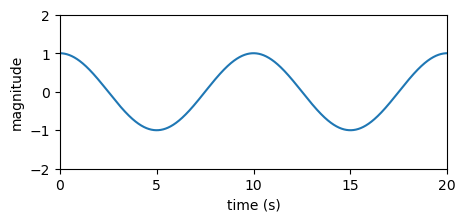

In [54]:
plt.figure(figsize=(5, 2))
plt.xlabel("time (s)")
plt.xlim(0, duration)
plt.xticks(np.arange(0, 21, 5))
plt.ylabel("magnitude")
plt.ylim(-2, 2)
plt.plot(t, y)

In [45]:
sampling_duration_equal_to_period = 10
sampling_duration_less_than_period = 8
sampling_duration_greater_than_period = 12
sampling_rate = 1

In [46]:
samples_equal_to_period = sampling_rate * sampling_duration_equal_to_period
samples_less_than_period = sampling_rate * sampling_duration_less_than_period
samples_greater_than_period = sampling_rate * sampling_duration_greater_than_period

In [ ]:
t_equal_to_period = np.linspace(
    0, sampling_duration_equal_to_period - 1, samples_equal_to_period
)
t_less_than_period = np.linspace(
    0, sampling_duration_less_than_period - 1, samples_less_than_period
)
t_greater_than_period = np.linspace(
    0, sampling_duration_greater_than_period - 1, samples_greater_than_period
)

In [92]:
len(t_equal_to_period), len(t_less_than_period), len(t_greater_than_period)

(10, 8, 12)

In [102]:
t_equal_to_period, t_less_than_period, t_greater_than_period

(array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.]),
 array([0., 1., 2., 3., 4., 5., 6., 7.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.]))

In [103]:
y_equal_to_period = wave(freq, 0, t_equal_to_period)
y_less_than_period = wave(freq, 0, t_less_than_period)
y_greater_than_period = wave(freq, 0, t_greater_than_period)

In [ ]:
import matplotlib.pyplot as plt


def plot_discrete_signal(time, signal):
    plt.figure(figsize=(5, 2))
    plt.xlabel("time (s)")
    plt.xlim(0, len(time) - 1)
    plt.xticks(np.arange(0, len(time), 1))
    plt.ylabel("magnitude")
    plt.ylim(-2, 2)
    markerline, stemline, baseline = plt.stem(
        time,
        signal,
        linefmt="-",
        markerfmt="o",
        basefmt="black",
    )
    markerline.set_markerfacecolor("none")
    plt.autoscale()
    plt.show()

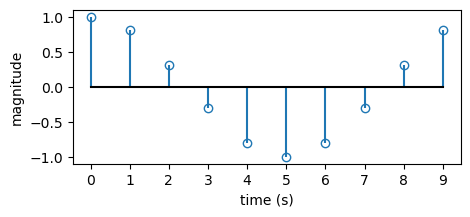

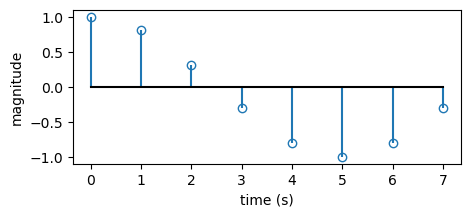

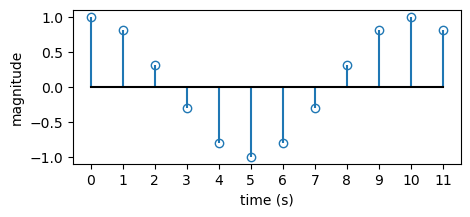

In [177]:
plot_discrete_signal(t_equal_to_period, y_equal_to_period)
plot_discrete_signal(t_less_than_period, y_less_than_period)
plot_discrete_signal(t_greater_than_period, y_greater_than_period)

In [120]:
fft_equal_to_period = np.fft.fft(y_equal_to_period)[: samples_equal_to_period // 2]
fft_less_than_period = np.fft.fft(y_less_than_period)[: samples_less_than_period // 2]
fft_greater_than_period = np.fft.fft(y_greater_than_period)[
    : samples_greater_than_period // 2
]

In [121]:
fft_equal_to_period

array([-3.33066907e-16+0.00000000e+00j,  5.00000000e+00-5.55111512e-16j,
        1.45330081e-16+1.05588484e-16j,  0.00000000e+00+2.43396349e-16j,
        2.12033730e-17+6.52572721e-17j])

In [122]:
magnitude_spectrum_equal_to_period = np.abs(fft_equal_to_period)
magnitude_spectrum_less_than_period = np.abs(fft_less_than_period)
magnitude_spectrum_greater_than_period = np.abs(fft_greater_than_period)

In [124]:
freq_bins = np.fft.fftfreq(len(t_equal_to_period), d=1 / sampling_rate)[
    : samples_equal_to_period // 2
]

In [180]:
import matplotlib.pyplot as plt


def plot_magnitude_spectrum(freq_bins, spectrum):
    plt.figure(figsize=(5, 2))
    plt.xlabel("Frequency (Hz)")
    plt.xlim(0, max(freq_bins))
    plt.xticks(freq_bins)
    plt.ylabel("Magnitude")
    plt.ylim(bottom=0)
    plt.yticks(np.arange(0, np.max(spectrum) + 2, 1))
    markerline, stemline, baseline = plt.stem(
        freq_bins,
        spectrum,
        linefmt="r-",
        markerfmt="o",
        basefmt="black",
    )
    markerline.set_markerfacecolor("none")
    baseline.set_lw(1)
    plt.autoscale()
    plt.show()

In [148]:
freq_bins

array([0. , 0.1, 0.2, 0.3, 0.4])

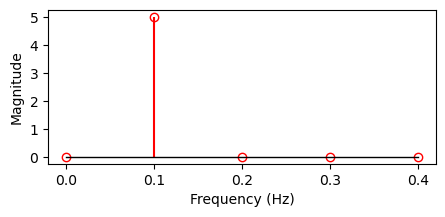

In [181]:
plot_magnitude_spectrum(freq_bins, magnitude_spectrum_equal_to_period)

In [199]:
phase_spectrum = np.angle(fft_equal_to_period)

In [200]:
import matplotlib.pyplot as plt


def plot_phase_spectrum(freq_bins, phase_spectrum):
    plt.figure(figsize=(5, 2))
    plt.xlabel("Frequency (Hz)")
    plt.xlim(0, max(freq_bins))
    plt.xticks(freq_bins)
    plt.ylabel("Phase (radians)")
    plt.ylim(-np.pi, np.pi)
    plt.yticks(np.arange(-np.pi, np.pi + 1, 1))
    markerline, stemline, baseline = plt.stem(
        freq_bins,
        phase_spectrum,
        linefmt="g-",
        markerfmt="o",
        basefmt="black",
    )
    markerline.set_markerfacecolor("none")
    baseline.set_lw(1)
    plt.autoscale()
    plt.show()

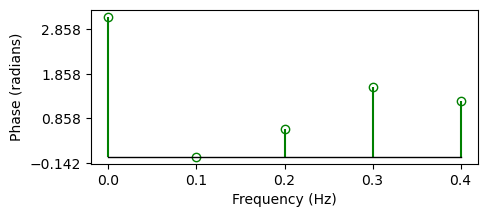

In [201]:
plot_phase_spectrum(freq_bins, phase_spectrum)